In [8]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv("../data/used_car.csv")

In [10]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [11]:
df.shape

(17966, 9)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [13]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [14]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(154)

In [16]:
df.nunique()

model              24
year               23
price            3511
transmission        3
mileage         13528
fuelType            5
tax                36
mpg                90
engineSize         16
dtype: int64

In [17]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [18]:
df.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

## Exploratory Data Analysis

<Axes: xlabel='price', ylabel='Count'>

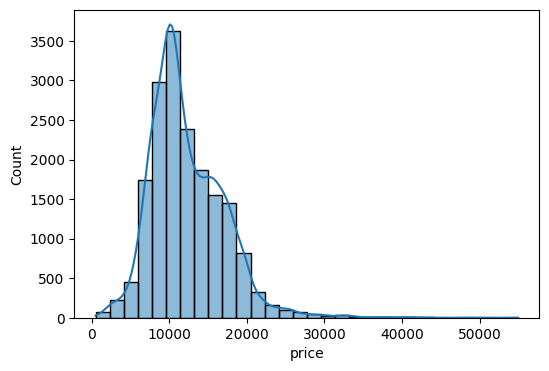

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='price', bins=30, kde=True)


<Axes: >

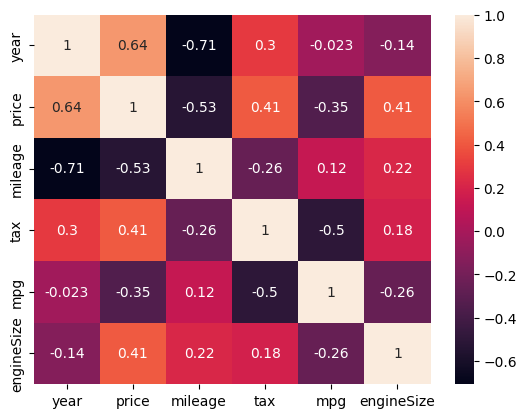

In [20]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

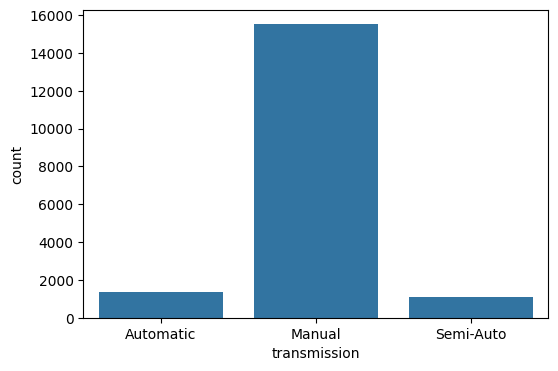

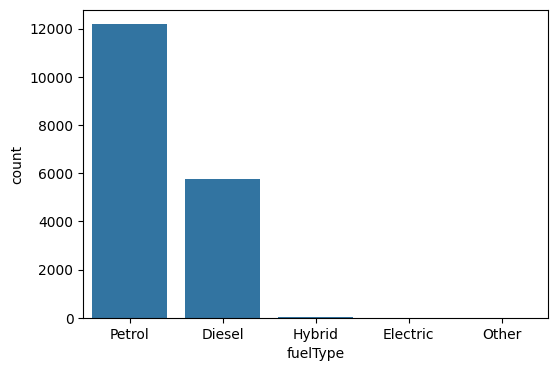

In [21]:
cat_cols = df.select_dtypes(include = 'object').columns

for col in cat_cols:
    if col != 'model':
        plt.figure(figsize=(6,4))
        sns.countplot(data=df,x = df[col])


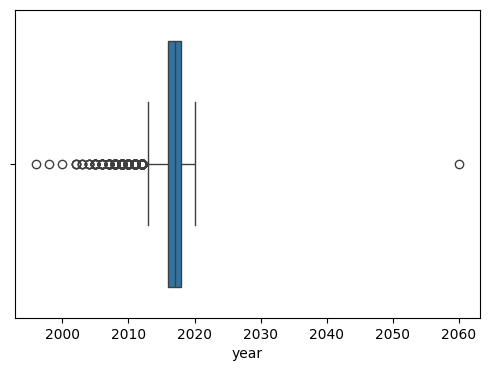

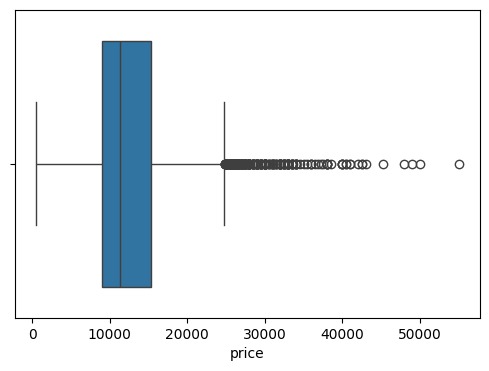

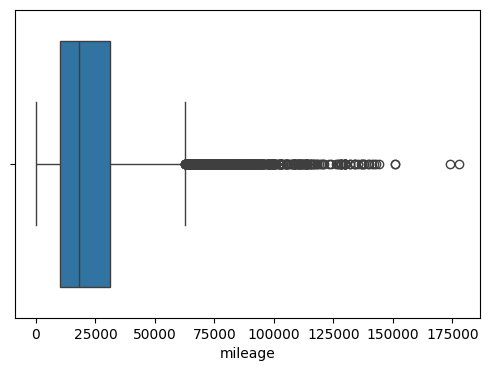

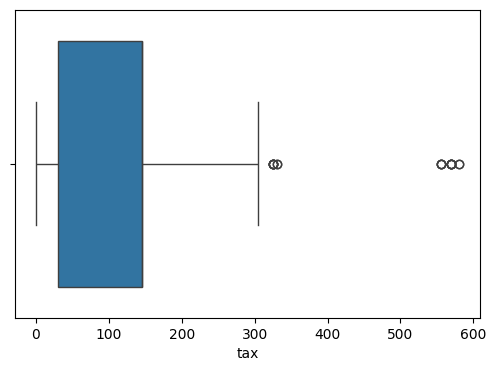

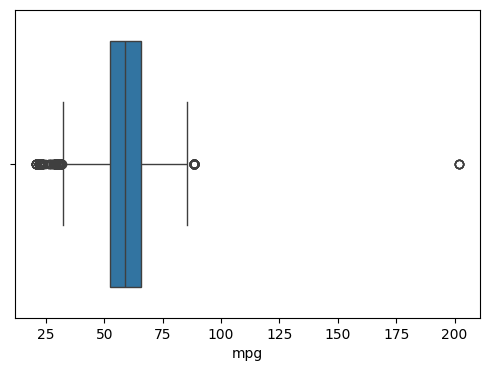

In [22]:
num = df.select_dtypes(include = 'number').columns

for col in num:
    if col != 'engineSize':
        plt.figure(figsize=(6,4))
        sns.boxplot(x= df[col])

In [23]:
df[num].skew()

year         -1.282601
price         1.096457
mileage       1.842068
tax          -0.564082
mpg           0.603923
engineSize    1.893121
dtype: float64

<Axes: xlabel='mileage', ylabel='price'>

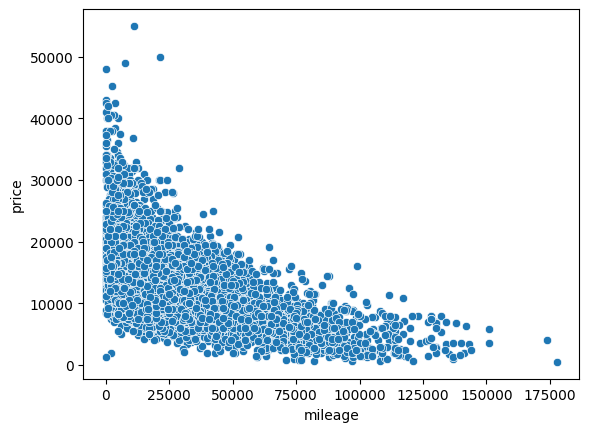

In [24]:
sns.scatterplot(x="mileage", y="price", data=df)

<Axes: xlabel='engineSize', ylabel='price'>

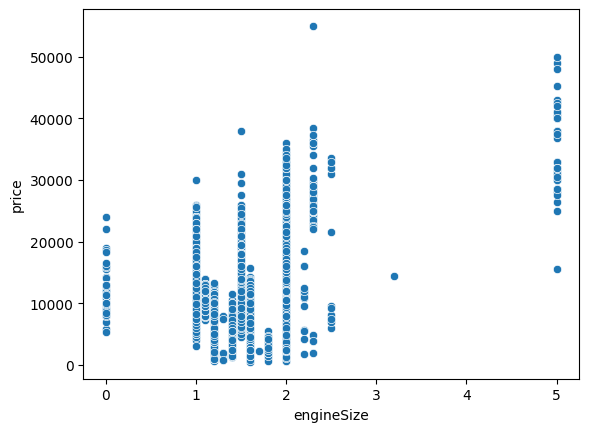

In [25]:
sns.scatterplot(x="engineSize", y="price", data=df)

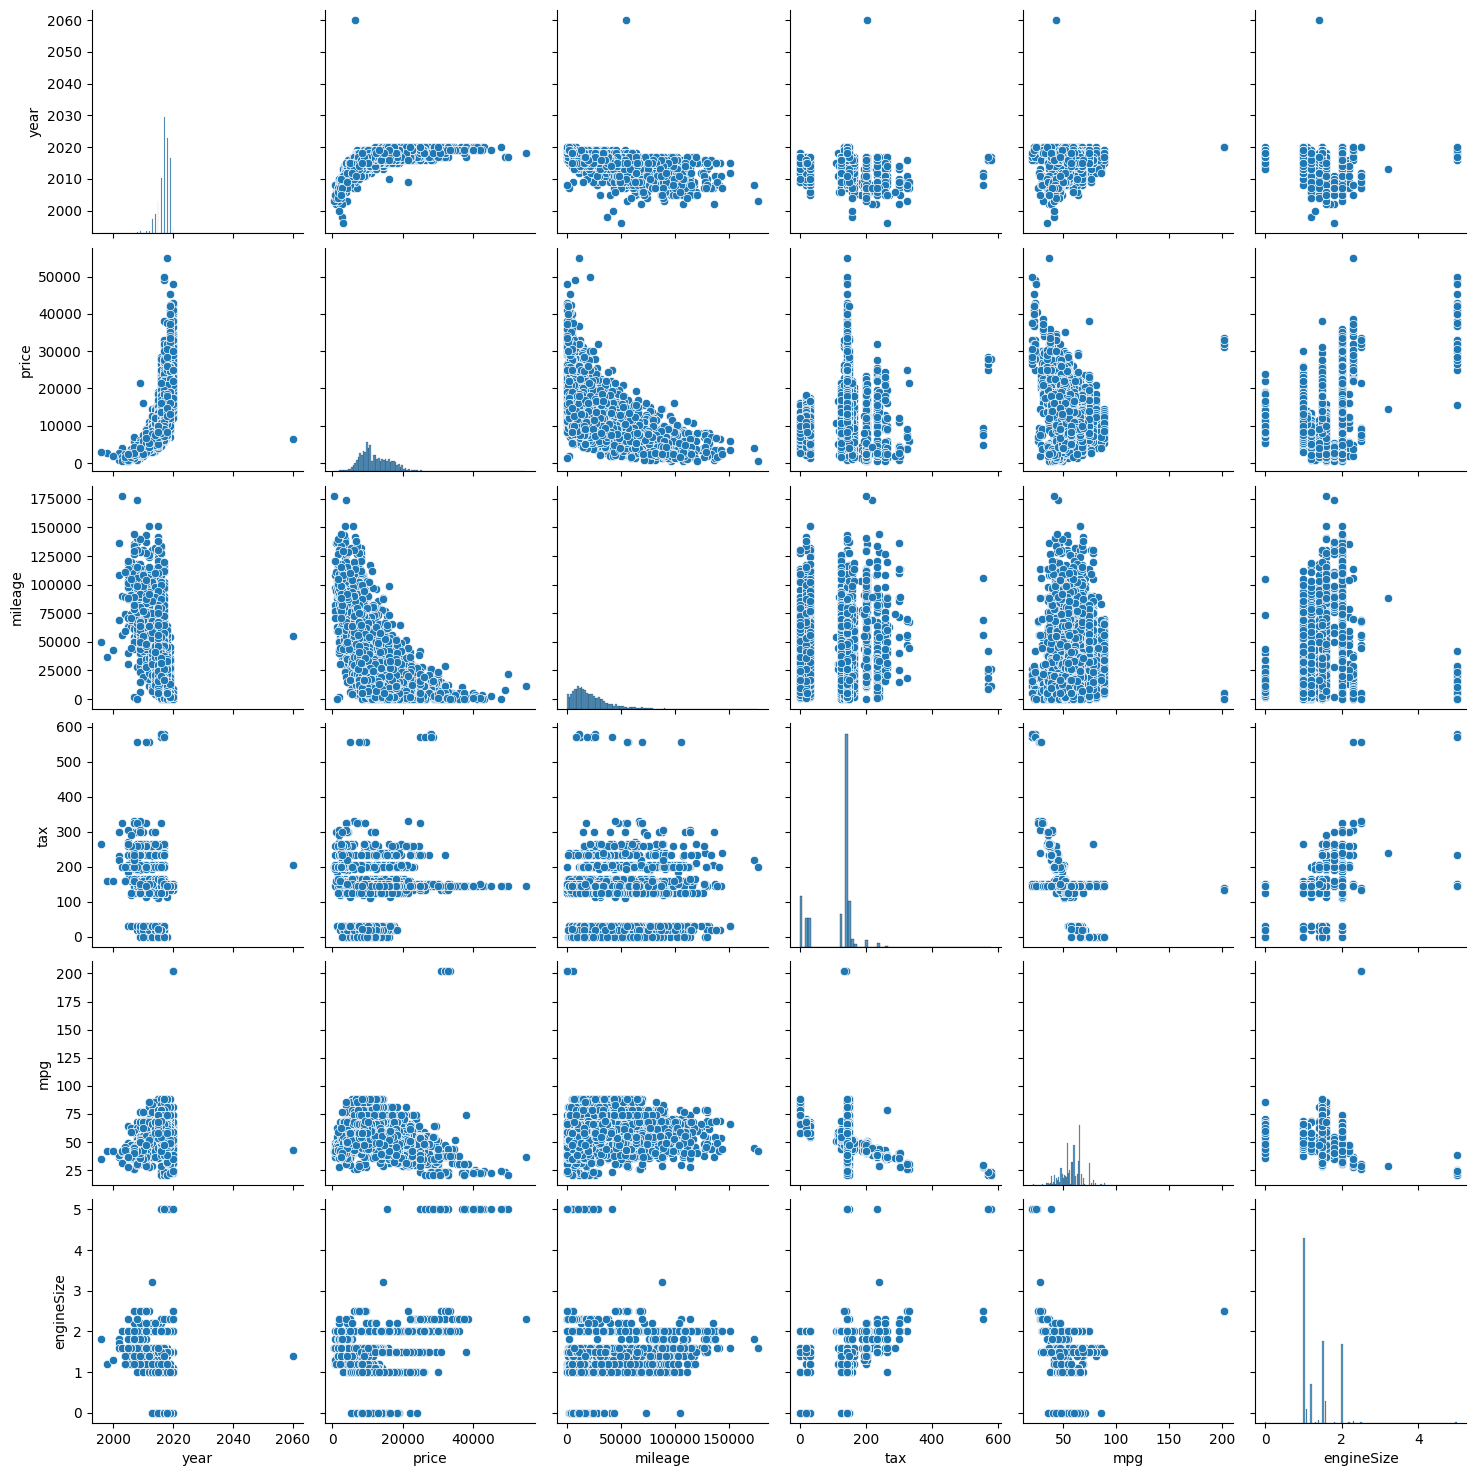

In [26]:
sns.pairplot(df[num])

# Data Preprocessing

In [27]:
df_cleaned = df.copy()

In [28]:
df_cleaned.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [29]:
df_cleaned.shape

(17966, 9)

In [30]:
df_cleaned.drop_duplicates(inplace=True)

In [31]:
df_cleaned.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [32]:

df_cleaned.duplicated().sum()

np.int64(0)

In [33]:
X = df_cleaned.drop(columns = ['price'],axis = 1)
y = df_cleaned['price']

In [34]:
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [35]:
from sklearn.preprocessing import LabelEncoder

columns = ['model','transmission','fuelType']

label_encoders = {}

for col in columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le



In [36]:
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


# Feature Engineering

In [37]:
from sklearn.preprocessing import StandardScaler
cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()
X[cols] = scaler.fit_transform(X[cols])

In [38]:
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,0.067059,0,-0.382994,4,0.591380,-0.020597,-0.810561
1,6,0.554393,1,-0.736317,4,0.591380,-0.020597,-0.810561
2,6,0.067059,1,-0.562616,4,0.591380,-0.020597,-0.810561
3,5,1.041726,1,-0.665405,4,0.510777,-1.737858,0.345325
4,5,1.041726,0,-1.127749,4,0.510777,-0.908836,-0.810561
...,...,...,...,...,...,...,...,...
17961,0,0.067059,1,-0.344061,4,0.591380,-1.066745,0.114148
17962,0,-1.394942,1,0.891875,4,-1.343079,-0.020597,-0.810561
17963,6,-0.907608,1,-0.843071,0,-1.504284,0.926858,0.576502
17964,11,0.554393,1,-0.946220,4,0.510777,-0.020597,-0.348206


In [39]:
df_cleaned.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [40]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17812 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17812 non-null  object 
 1   year          17812 non-null  int64  
 2   price         17812 non-null  int64  
 3   transmission  17812 non-null  object 
 4   mileage       17812 non-null  int64  
 5   fuelType      17812 non-null  object 
 6   tax           17812 non-null  int64  
 7   mpg           17812 non-null  float64
 8   engineSize    17812 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.4+ MB


In [42]:
df_cleaned.corr(numeric_only=True)["price"]

year          0.635715
price         1.000000
mileage      -0.530483
tax           0.405969
mpg          -0.346263
engineSize    0.411451
Name: price, dtype: float64

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)  

model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("Mean Squared Error:", mse)
print("R-squared:", round(r2, 2))
print("Adjusted R-squared:", round(adjusted_r2, 2))

Mean Squared Error: 6599333.038334266
R-squared: 0.71
Adjusted R-squared: 0.71
